In [1]:
#| include: false

# /// script
# requires-python = ">=3.10"
# dependencies = [
#   "matplotlib",
#   "numpy",
#   "pymc",
#   "scikit-learn",
#   "seaborn",
# ]
# ///


In [2]:
%matplotlib inline
import pytensor
import pymc as pm
import arviz as az
import pytensor.tensor as pt
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from warnings import filterwarnings
from sklearn import datasets
from sklearn.preprocessing import scale
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
sns.set_style('whitegrid')

In [3]:
X, Y = make_moons(noise=0.2, random_state=0, n_samples=1000)
X = scale(X)

In [4]:
Y = Y.astype('float64')

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=.5)

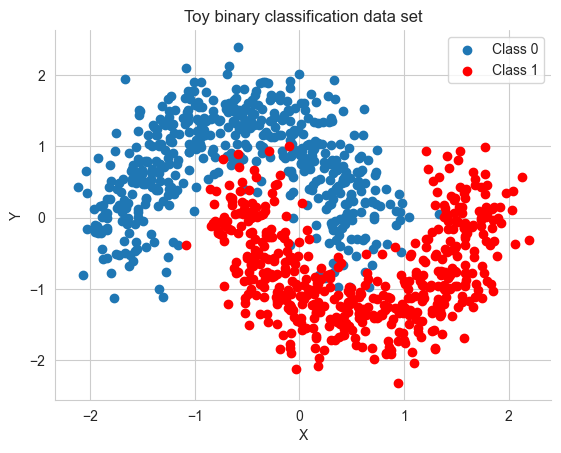

In [6]:
fig, ax = plt.subplots()
ax.scatter(X[Y==0, 0], X[Y==0, 1], label='Class 0')
ax.scatter(X[Y==1, 0], X[Y==1, 1], color='r', label='Class 1')
sns.despine(); ax.legend()
ax.set(xlabel='X', ylabel='Y', title='Toy binary classification data set');

In [7]:
X_train.shape

(500, 2)

In [8]:
def construct_nn(ann_input, ann_output):
    n_hidden = 5

    # Initialize random weights between each layer
    init_1 = np.random.randn(X.shape[1], n_hidden).astype(np.float64)
    init_2 = np.random.randn(n_hidden, n_hidden).astype(np.float64)
    init_out = np.random.randn(n_hidden).astype(np.float64)

    with pm.Model() as neural_network:
        # Weights from input to hidden layer
        weights_in_1 = pm.Normal('w_in_1', 0, sigma=1,
                                 shape=(X.shape[1], n_hidden),
                                 initval=init_1)

        # Weights from 1st to 2nd layer
        weights_1_2 = pm.Normal('w_1_2', 0, sigma=1,
                                shape=(n_hidden, n_hidden),
                                initval=init_2)

        # Weights from hidden layer to output
        weights_2_out = pm.Normal('w_2_out', 0, sigma=1,
                                  shape=(n_hidden,),
                                  initval=init_out)

        # Build neural-network using tanh activation function
        act_1 = pm.math.tanh(pm.math.dot(ann_input,
                                         weights_in_1))
        act_2 = pm.math.tanh(pm.math.dot(act_1,
                                         weights_1_2))
        act_out = pm.math.sigmoid(pm.math.dot(act_2,
                                              weights_2_out))

        # Binary classification -> Bernoulli likelihood
        out = pm.Bernoulli('out',
                           p=act_out,
                           observed=ann_output,
                           total_size=Y_train.shape[0] # IMPORTANT for minibatches
                          )
    return neural_network

# Trick: Turn inputs and outputs into shared variables.
# It's still the same thing, but we can later change the values of the shared variable
# (to switch in the test-data later) and pymc will just use the new data.
# Kind-of like a pointer we can redirect.
ann_input = pytensor.shared(X_train)
ann_output = pytensor.shared(Y_train)
neural_network = construct_nn(ann_input, ann_output)

In [9]:
with neural_network:
    nutstrace = pm.sample(2000, tune=1000)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [w_in_1, w_1_2, w_2_out]


/Users/rahul/Library/Caches/uv/archive-v0/wV-uT_3pb4u247-POgKgx/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 86 seconds.


There were 1324 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [10]:
az.summary(nutstrace)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"w_in_1[0, 0]",-0.252,1.517,-3.140,2.490,0.235,0.076,48.0,243.0,1.09
"w_in_1[0, 1]",0.491,1.602,-2.438,3.289,0.337,0.083,25.0,203.0,1.11
"w_in_1[0, 2]",-0.230,1.559,-3.060,2.722,0.174,0.136,85.0,167.0,1.03
"w_in_1[0, 3]",-0.006,1.327,-2.855,2.509,0.134,0.083,105.0,90.0,1.03
"w_in_1[0, 4]",-0.067,1.507,-2.828,2.824,0.152,0.088,107.0,273.0,1.05
"w_in_1[1, 0]",0.095,0.673,-1.151,1.740,0.063,0.043,112.0,223.0,1.03
"w_in_1[1, 1]",0.109,0.670,-1.344,1.489,0.088,0.045,51.0,192.0,1.07
"w_in_1[1, 2]",-0.025,0.575,-1.255,1.280,0.042,0.035,182.0,280.0,1.02
"w_in_1[1, 3]",-0.047,0.607,-1.451,1.246,0.035,0.037,295.0,348.0,1.03
"w_in_1[1, 4]",-0.020,0.623,-1.367,1.339,0.037,0.046,268.0,387.0,1.03


In [11]:
with neural_network:
    inference = pm.ADVI()
    approx = pm.fit(n=30000, method=inference)

/Users/rahul/Library/Caches/uv/archive-v0/wV-uT_3pb4u247-POgKgx/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 170.33


In [12]:
advitrace = approx.sample(draws=5000)

In [13]:
az.summary(advitrace)

arviz - WARNING - Shape validation failed: input_shape: (1, 5000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"w_in_1[0, 0]",0.205,0.392,-0.539,0.904,0.006,0.004,4488.0,5023.0,NaN
"w_in_1[0, 1]",0.545,0.136,0.285,0.791,0.002,0.001,4718.0,4809.0,NaN
"w_in_1[0, 2]",-2.102,0.556,-3.149,-1.092,0.008,0.006,4495.0,4604.0,NaN
"w_in_1[0, 3]",0.560,0.132,0.304,0.804,0.002,0.001,5250.0,4973.0,NaN
"w_in_1[0, 4]",-0.208,0.527,-1.169,0.809,0.007,0.005,4996.0,4938.0,NaN
"w_in_1[1, 0]",-0.246,0.531,-1.229,0.789,0.008,0.005,4596.0,4611.0,NaN
"w_in_1[1, 1]",-0.478,0.255,-0.939,0.005,0.004,0.003,4909.0,4759.0,NaN
"w_in_1[1, 2]",-1.276,0.527,-2.258,-0.263,0.008,0.005,4894.0,4982.0,NaN
"w_in_1[1, 3]",-0.490,0.214,-0.889,-0.081,0.003,0.002,4709.0,4972.0,NaN
"w_in_1[1, 4]",0.390,0.637,-0.821,1.552,0.009,0.007,4960.0,4601.0,NaN


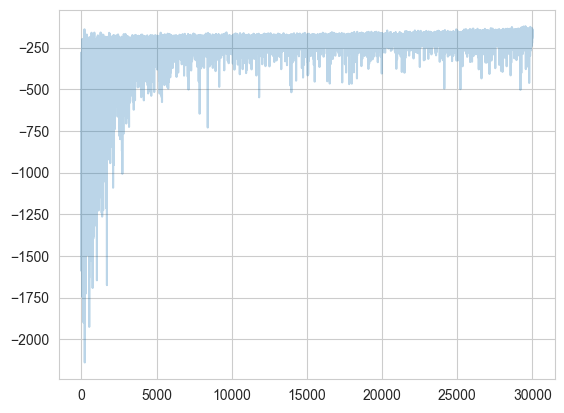

In [14]:
plt.plot(-inference.hist, alpha=.3)

In [15]:
ann_input.set_value(X_test)
ann_output.set_value(Y_test)
with neural_network:
    ppc = pm.sample_posterior_predictive(advitrace)

Sampling: [out]


/Users/rahul/Library/Caches/uv/archive-v0/wV-uT_3pb4u247-POgKgx/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

In [16]:
pred = ppc.posterior_predictive['out'].values.reshape(-1, X_test.shape[0]).mean(axis=0) > 0.5

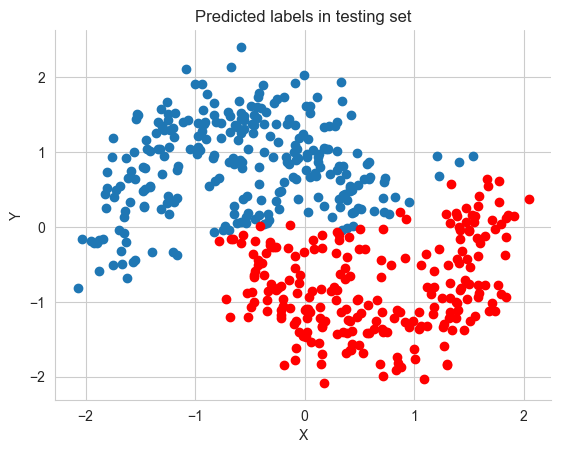

In [17]:
fig, ax = plt.subplots()
ax.scatter(X_test[pred==0, 0], X_test[pred==0, 1])
ax.scatter(X_test[pred==1, 0], X_test[pred==1, 1], color='r')
sns.despine()
ax.set(title='Predicted labels in testing set', xlabel='X', ylabel='Y');

In [18]:
print('Accuracy = {}%'.format((Y_test == pred).mean() * 100))

Accuracy = 88.8%


In [19]:
grid = pm.floatX(np.mgrid[-3:3:100j,-3:3:100j])
grid_2d = grid.reshape(2, -1).T
dummy_out = np.ones(grid_2d.shape[0], dtype=np.float64)

In [20]:
ann_input.set_value(grid_2d)
ann_output.set_value(dummy_out)
with neural_network:
    ppc_grid = pm.sample_posterior_predictive(advitrace, var_names=['out'])

Sampling: [out]


/Users/rahul/Library/Caches/uv/archive-v0/wV-uT_3pb4u247-POgKgx/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

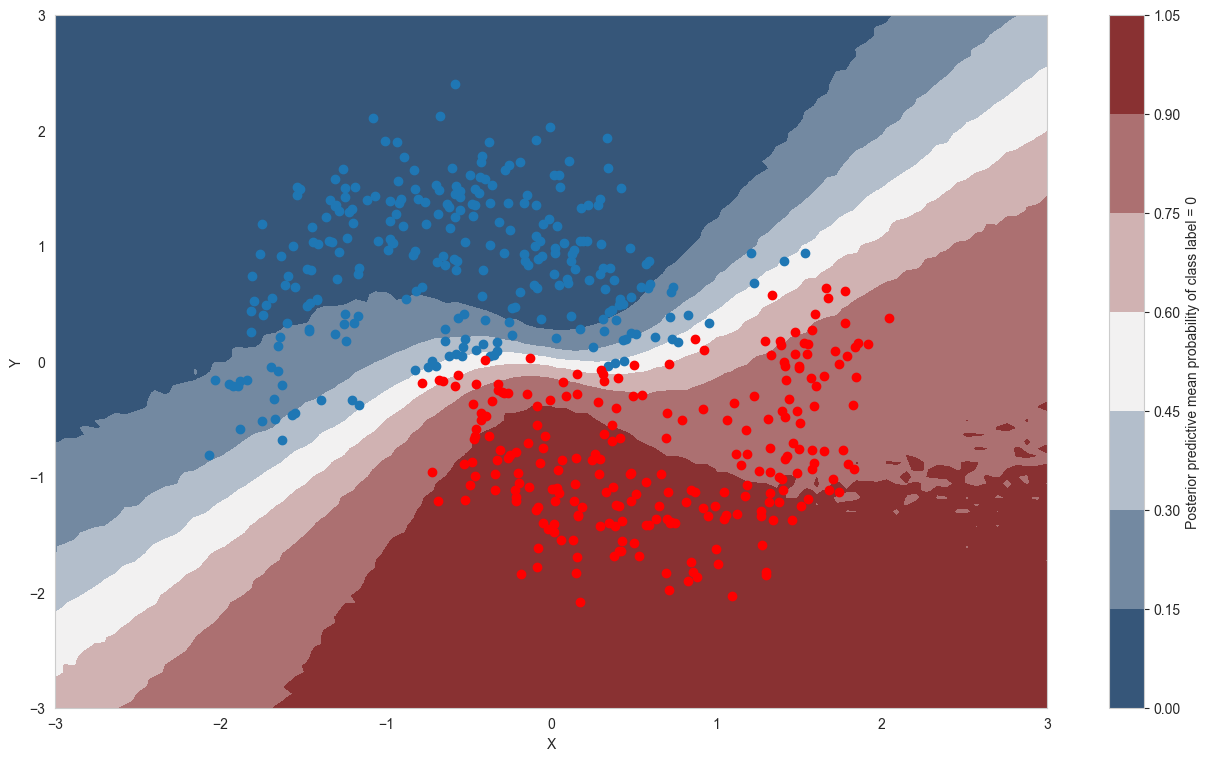

In [21]:
cmap = sns.diverging_palette(250, 12, s=85, l=25, as_cmap=True)
fig, ax = plt.subplots(figsize=(16, 9))
ppc_out_mean = ppc_grid.posterior_predictive['out'].values.reshape(-1, grid_2d.shape[0]).mean(axis=0)
contour = ax.contourf(grid[0], grid[1], ppc_out_mean.reshape(100, 100), cmap=cmap)
ax.scatter(X_test[pred==0, 0], X_test[pred==0, 1])
ax.scatter(X_test[pred==1, 0], X_test[pred==1, 1], color='r')
cbar = plt.colorbar(contour, ax=ax)
_ = ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel='X', ylabel='Y');
cbar.ax.set_ylabel('Posterior predictive mean probability of class label = 0');

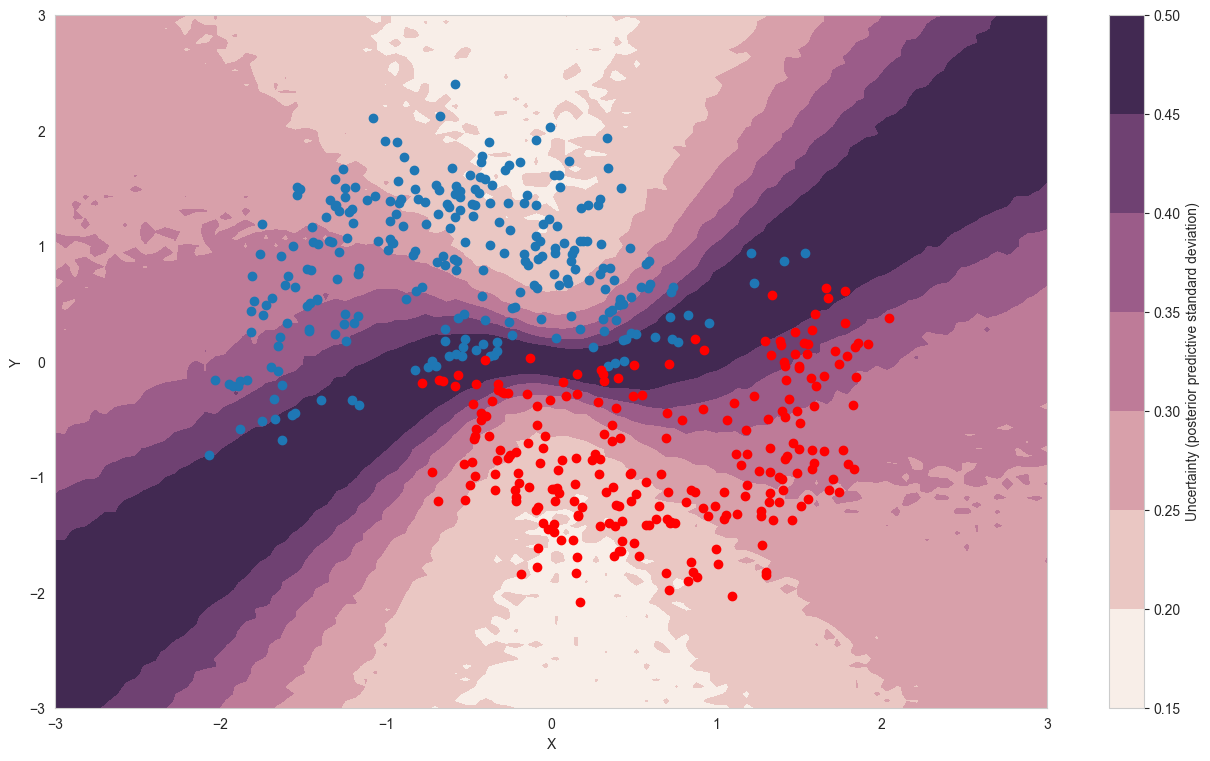

In [22]:
cmap = sns.cubehelix_palette(light=1, as_cmap=True)
fig, ax = plt.subplots(figsize=(16, 9))
ppc_out_std = ppc_grid.posterior_predictive['out'].values.reshape(-1, grid_2d.shape[0]).std(axis=0)
contour = ax.contourf(grid[0], grid[1], ppc_out_std.reshape(100, 100), cmap=cmap)
ax.scatter(X_test[pred==0, 0], X_test[pred==0, 1])
ax.scatter(X_test[pred==1, 0], X_test[pred==1, 1], color='r')
cbar = plt.colorbar(contour, ax=ax)
_ = ax.set(xlim=(-3, 3), ylim=(-3, 3), xlabel='X', ylabel='Y');
cbar.ax.set_ylabel('Uncertainty (posterior predictive standard deviation)');

In [23]:
minibatch_x = pm.Minibatch(X_train, batch_size=50)
minibatch_y = pm.Minibatch(Y_train, batch_size=50)
neural_network_minibatch = construct_nn(minibatch_x, minibatch_y)
with neural_network_minibatch:
    approx_mb = pm.fit(40000, method=pm.ADVI())

/Users/rahul/Library/Caches/uv/archive-v0/wV-uT_3pb4u247-POgKgx/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Finished [100%]: Average Loss = 35.717


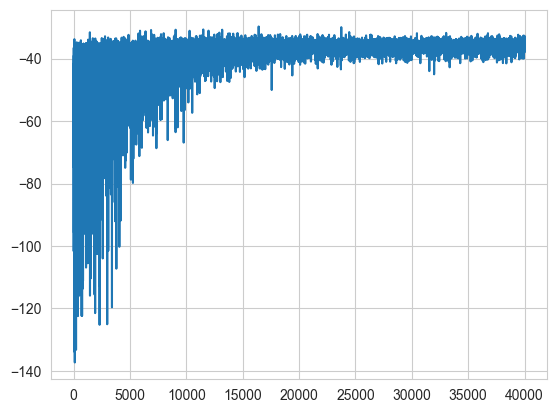

In [24]:
plt.plot(-approx_mb.hist)